# Modélisation : Telco Customer Churn

## Objectif
Entraîner un modèle de régression logistique pour prédire le risque de résiliation, évaluer ses performances avec les métriques adaptées à la classification (matrice de confusion, précision, rappel, F1, ROC-AUC), et interpréter les coefficients pour identifier les facteurs de churn.

## Étapes
1. Chargement du dataset final
2. Séparation features / cible et split train/test
3. Entraînement du modèle
4. Évaluation (matrice de confusion, précision, rappel, F1)
5. Courbe ROC et AUC
6. Interprétation des coefficients
7. Sauvegarde du modèle

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, 
                               precision_score, recall_score, f1_score, 
                               roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/telco_final.csv')
print(df.shape)
df.head()

(7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,0,0,1,0,...,1,-1.160323,0,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,1,0,1,...,0,-0.259629,0,False,False,True,False,False,False,True
2,1,0,0,0,-1.236724,1,0,1,1,0,...,1,-0.362660,1,False,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,0,1,0,1,...,0,-0.746535,0,False,False,True,False,False,False,False
4,0,0,0,0,-1.236724,1,0,0,0,0,...,1,0.197365,1,True,False,False,False,False,True,False


In [2]:
# séparation features / cible et split train/test
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train :', X_train.shape)
print('Test :', X_test.shape)
print(y_train.value_counts(normalize=True))

Train : (5634, 22)
Test : (1409, 22)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [4]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

print("Modele entraine")

Modele entraine


In [5]:
y_pred_proba = model_balanced.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.4).astype(int)

print("Matrice de confusion (seuil 0.4) :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC : {auc:.4f}")

Matrice de confusion (seuil 0.4) :
[[669 366]
 [ 53 321]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409

AUC : 0.8388


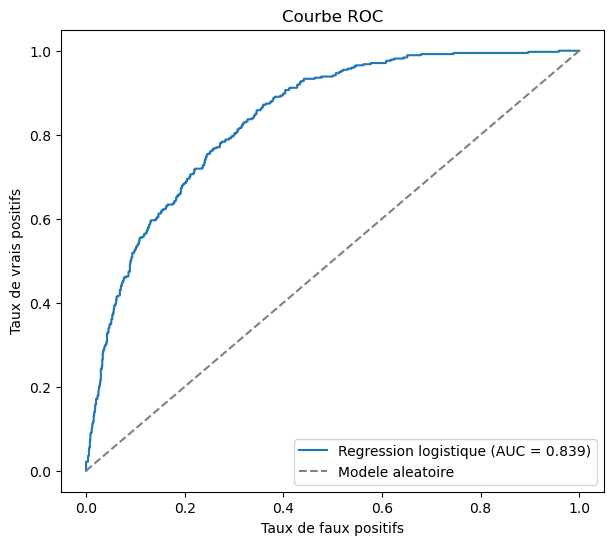

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Regression logistique (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modele aleatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend()
plt.show()

In [7]:
coefficients = pd.Series(model_balanced.coef_[0], index=X.columns).sort_values(ascending=False)

print("Top 10 facteurs qui augmentent le risque de churn :")
print(coefficients.head(10))

print("\nTop 10 facteurs qui diminuent le risque de churn :")
print(coefficients.tail(10))

Top 10 facteurs qui augmentent le risque de churn :
InternetService_Fiber optic       1.121507
PaymentMethod_Electronic check    0.400824
StreamingMovies                   0.393871
StreamingTV                       0.370546
PaperlessBilling                  0.334995
MultipleLines                     0.323242
SeniorCitizen                     0.151022
PaymentMethod_Mailed check        0.084242
DeviceProtection                  0.040177
gender                            0.038628
dtype: float64

Top 10 facteurs qui diminuent le risque de churn :
OnlineBackup         -0.068344
PhoneService         -0.232229
Dependents           -0.241232
MonthlyCharges       -0.265441
TechSupport          -0.273725
OnlineSecurity       -0.342480
Contract_One year    -0.722214
tenure               -0.758737
InternetService_No   -1.049070
Contract_Two year    -1.405858
dtype: float64


In [8]:
import joblib

joblib.dump(model_balanced, '../src/model_logistic.pkl')
joblib.dump(X.columns.tolist(), '../src/model_columns.pkl')

print("Modele et colonnes sauvegardes")

Modele et colonnes sauvegardes
